# Model Using Random Forest Regressor

## Load data

Install needed libraries

In [ ]:
%pip install pandas
%pip install scikit-learn
%pip install imbalanced-learn
%pip install seaborn matplotlib

In [80]:
import pandas as pd

full_data = pd.read_csv('../data/raw/nsw_crash_data_2020-2024.csv')

# # clean column names
# full_data.columns = (
#     full_data.columns
#     .str.strip()                      # remove leading/trailing spaces
#     .str.lower()                      # lowercase for consistency
#     .str.replace(' ', '_')            # replace spaces with underscores
#     .str.replace('-', '_')            # replace dashes with underscores
# )


# # get quick overview of data
# print(full_data.shape)
full_data.head()

,CrashID,DegreeOfCrash,DegreeOfCrashDetailed,ReportingYear,YearOfCrash,MonthOfCrash,DayOfWeekOfCrash,TwoHourIntervals,StreetOfCrash,StreetType,...,DCADescription,DCASupplement,FirstImpactType,KeyTUType,OtherTUType,NoOfTrafficUnitsInvolved,NoKilled,NoSeriouslyInjured,NoModeratelyInjured,NoMinorOtherInjured
0,1220987,Fatal,Fatal,2020,2020,January,Friday,22:00 - Midnight,HUME,HWY,...,Left off cway into object,NaN,Vehicle - Object,Semi-trailer,NaN,1,1,0,0,0
1,1220988,Fatal,Fatal,2020,2020,January,Friday,22:00 - Midnight,PACIFIC,HWY,...,Ped - Far side,NaN,Vehicle - Pedestrian,Car (sedan/hatch),Pedestrian,2,1,0,1,0
2,1221458,Fatal,Fatal,2020,2020,January,Friday,16:00 - 17:59,GOULBURN,RD,...,Off cway right bend,Left,Rollover,Motorcycle,NaN,1,1,0,0,0
3,1221459,Fatal,Fatal,2020,2020,January,Sunday,22:00 - Midnight,MARSDEN,RD,...,Ped - Far side,NaN,Vehicle - Pedestrian,Car (sedan/hatch),Pedestrian,2,1,0,1,0
4,1222080,Fatal,Fatal,2020,2020,January,Wednesday,02:00 - 03:59,SCOTT,ST,...,Left off cway into object,NaN,Vehicle - Object,Motorcycle,NaN,1,1,0,0,0


Split the data into test, validation, and training.

This code will split the data into these proportions:
- 60% training
- 20% validation
- 20% test

We will exclude the following columns as features:
- `CrashID`: no predictive meaning
- `DegreeOfCrash`: target
- `NoKilled`, `NoSeriouslyInjured`, `NoModeratelyInjured`, `NoMinorOtherInjured`: leakage
- `ReportingYear`, `YearOfCrash`: no predictive meaning
- `Distance`, `Direction`, `IdentifyingFeature`, `IdentifyingFeatureType`, `RouteNum`: Too specific, might add noise
- `Town`, `StreetOfCrash`: can use Latitute and Longitude instead

We will use the following colums as features of X to train and predict with:
- `MonthOfCrash`: seasonal, weather effects
- `DayOfWeekOfCrash`: weekend vs weekday patterns
- `TwoHourIntervals`: Night vs Day, rush hour effects
- `SchoolZoneActive`: true/false, speed limit difference
- `Urbanisation`: rural crash tends to be more severe
- `ConurbationOne`: broader reginal grouping
- `TypeOfLocation`: highway vs road vs street etc.
- `SpeedLimit`: one of the strongest predictors of severity
- `RoadClassificationAdmin`: Motorway vs local road — affects speed, control
- `Alignment`: Straight / curve — geometry affects control
- `StreetLighting`: Dark roads = higher severity risk
- `RoadSurface`: Asphalt / concrete — traction differences
- `SurfaceCondition`: Wet / dry — friction
- `Weather`: Rain, fog, fine — environmental influence
- `NaturalLighting`: Daylight / dusk / dark — visibility
- `SignalsOperation`: Signalised vs unsignalised intersection
- `OtherTrafficControl`: Stop sign, give way, etc.
- `FirstImpactType`: Head-on, side, rear, etc. — strong predictor of injury severity
- `DCACode`, `DCADescription`, `DCASupplement`: Detailed crash mechanism — very informative
- `NoOfTrafficUnitsInvolved`: Multi-vehicle crashes often more severe

In [81]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

features = [
    "MonthOfCrash",
    "DayOfWeekOfCrash",
    "TwoHourIntervals",
    "SchoolZoneActive",
    "Urbanisation",
    "ConurbationOne",
    "TypeOfLocation",
    "SpeedLimit",
    "RoadClassificationAdmin",
    "Alignment",
    "StreetLighting",
    "RoadSurface",
    "SurfaceCondition",
    "Weather",
    "NaturalLighting",
    "SignalsOperation",
    "OtherTrafficControl",
    "FirstImpactType",
    "DCACode",
    "DCADescription",
    "DCASupplement",
    "NoOfTrafficUnitsInvolved"
]

X = full_data[features]
le = LabelEncoder()
y_raw = full_data["DegreeOfCrashDetailed"]
print(np.unique(y_raw))
print(y_raw.value_counts(normalize=True))
y = le.fit_transform(y_raw)


from sklearn.model_selection import train_test_split

# split into train and test first --> keeping 20% for testing
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=12,
    stratify=y #keep same class ratio in each split
)

# split training data inot train and validation
# 75% train, 25% validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,
    random_state=12,
    stratify=y_train_full
)

X_train.head()

['Fatal' 'Minor/Other Injury' 'Moderate Injury' 'Non-casualty (towaway)'
 'Serious Injury']
DegreeOfCrashDetailed
Non-casualty (towaway)    0.320505
Moderate Injury           0.283385
Serious Injury            0.212552
Minor/Other Injury        0.168502
Fatal                     0.015056
Name: proportion, dtype: float64


,MonthOfCrash,DayOfWeekOfCrash,TwoHourIntervals,SchoolZoneActive,Urbanisation,ConurbationOne,TypeOfLocation,SpeedLimit,RoadClassificationAdmin,Alignment,...,SurfaceCondition,Weather,NaturalLighting,SignalsOperation,OtherTrafficControl,FirstImpactType,DCACode,DCADescription,DCASupplement,NoOfTrafficUnitsInvolved
52836,May,Saturday,08:00 - 09:59,Not a school zone,Sydney metro. area,Syd-Newc-Woll Gtr conurbation,T-junction,50 km/h,State,Straight,...,Dry,Fine,Daylight,On,Ped crossing,Vehicle - Pedestrian,3,Ped - Far side,NaN,3
55311,June,Wednesday,16:00 - 17:59,Not a school zone,Country urban,Rest of NSW - Urban,2-way undivided,60 km/h,Local,Curved,...,Dry,Fine,Dusk,Nil,No traffic controls,Vehicle - Object,803,Off right bend into obj,Left,1
59263,August,Friday,10:00 - 11:59,Not a school zone,Sydney metro. area,Syd-Newc-Woll Gtr conurbation,T-junction,60 km/h,State,Straight,...,Dry,Fine,Daylight,Nil,Stop sign,Other angle,202,Opp - Right-thru,NaN,2
49345,November,Friday,18:00 - 19:59,Not a school zone,Sydney metro. area,Syd-Newc-Woll Gtr conurbation,2-way undivided,50 km/h,Local,Straight,...,Dry,Fine,Daylight,Nil,No traffic controls,Other angle,703,Left off cway into object,NaN,3
86413,November,Sunday,04:00 - 05:59,Not a school zone,Sydney metro. area,Syd-Newc-Woll Gtr conurbation,2-way undivided,50 km/h,Local,Straight,...,Wet,Raining,Darkness,Nil,No traffic controls,Other angle,703,Left off cway into object,NaN,2


We can see that fatal is only 1.5%. This shows that our daat is imbalanced. This means that a model that always predicts the majority class (“Non-casualty”) would already get ~32% accuracy.

I ran the model without dealing with this and got a validation accuracy of 45.95%.

Preprocess data

In [82]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

object_cols = [col for col in X_train.columns if X_train[col].dtype == "object"]
num_cols = [col for col in X_train.columns if X_train[col].dtype != "object"]
print("Categorical datas: ", object_cols)
print("Numerical datas: ", num_cols)

# print(len(object_cols))
# print(len(num_cols))

# impute numerical data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# OH encode categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# combine these transformers into one ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('cat', categorical_transformer, object_cols)
    ])


Categorical datas:  ['MonthOfCrash', 'DayOfWeekOfCrash', 'TwoHourIntervals', 'SchoolZoneActive', 'Urbanisation', 'ConurbationOne', 'TypeOfLocation', 'SpeedLimit', 'RoadClassificationAdmin', 'Alignment', 'StreetLighting', 'RoadSurface', 'SurfaceCondition', 'Weather', 'NaturalLighting', 'SignalsOperation', 'OtherTrafficControl', 'FirstImpactType', 'DCADescription', 'DCASupplement']
Numerical datas:  ['DCACode', 'NoOfTrafficUnitsInvolved']


Construct pipeline. Create the model and train it

Macro F1 Score: 0.3783

Classification Report:

              precision    recall  f1-score   support

           0       0.20      0.09      0.12       277
           1       0.42      0.26      0.32      3107
           2       0.40      0.36      0.38      5225
           3       0.59      0.68      0.63      5910
           4       0.39      0.48      0.43      3919

    accuracy                           0.47     18438
   macro avg       0.40      0.38      0.38     18438
weighted avg       0.46      0.47      0.46     18438



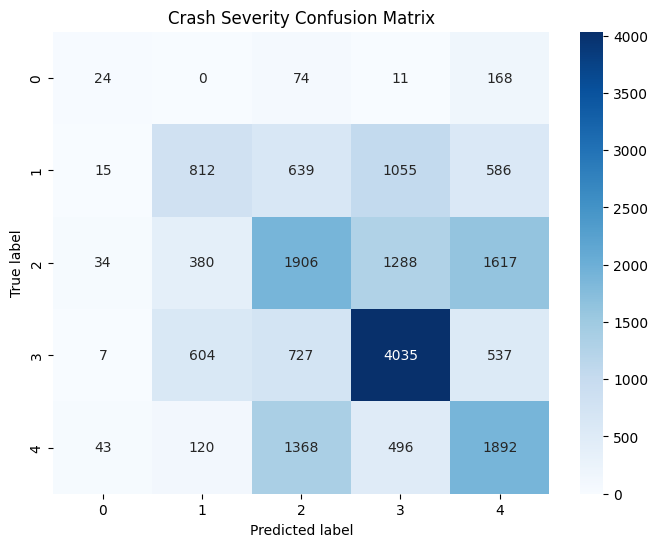

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import seaborn as sns
import matplotlib.pyplot as plt

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced_subsample' # gives more weight to rare classes like “Fatal” during training.
)

clf = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),   # oversampling step
    ('model', model)
])

clf.fit(X_train, y_train)
predictions = clf.predict(X_valid)

# Macro F1 (better for imbalanced multi-class)
macro_f1 = f1_score(y_valid, predictions, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_valid, predictions))

# Confusion Matrix
cm = confusion_matrix(y_valid, predictions, labels=clf.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Crash Severity Confusion Matrix")
plt.show()

With this, we are able to get an accuracy of 47%, roughly double random chance (20%) which gives ups a strong baseline. The model also easily recognises the majority class, as seen with the heat map. 

It takes around 7 minutes to train this model.

We can improve this model by merge semantically similar classes like fatal + serious into severe. But for an initial random forest regression model, I don't think there is a need to further explore this. Rather, working on a gradient boosted trees model like XGBoost will yield much better results.

Save the model

In [90]:
import joblib

joblib.dump(clf, "../models/crash_severity_pipeline.pkl")
print("\n💾 Model saved as 'models/crash_severity_pipeline.pkl'")


💾 Model saved as 'models/crash_severity_pipeline.pkl'
